# Week 9 — validation and governance (Wednesday, 1 hour)

Six exercises on fc-10's `apply`, `validation` and `paper` modules, the challenge memos, and Decision 7. Every rate is
**PLANTED TRUTH**, and nothing here writes to fc-10: the apply exercise works on a scratch copy of the registry.
Read `README.md` in this folder first.

In [1]:
import json, re, shutil, sys, tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
apply = fc10_module("runtime.manufacturing.tuning.apply")
validation = fc10_module("runtime.manufacturing.tuning.validation")
paper = fc10_module("runtime.manufacturing.tuning.paper")
decision_log = fc10_module("runtime.manufacturing.tuning.decision_log")
registry_mod = fc10_module("runtime.manufacturing.data_model.tm_rule_registry")

[d7] = [e for e in decision_log.load() if e["decision_id"] == "D7"]
ev = d7["evidence"]
print(d7["decision"], d7["validation_verdict"], "· candidate:", d7["candidate"]["name"],
      "· challenger to beat:", d7["challenger_to_beat"]["name"])

HOLD NOT_YET_VALIDATED · candidate: d3_lines · challenger to beat: spike_floor+d3_lines


## Exercise 1 — the apply step refuses a surprise

A drill decision moves £75k to £98k. Give it the full predictions, then only the TM-SIM one, and watch what the
step does. Everything is written to a scratch copy of the registry.

In [2]:
tmp = Path(tempfile.mkdtemp())
reg_path = tmp / "tm_rule_registry.json"
shutil.copy(registry_mod._REGISTRY_PATH, reg_path)
registry = registry_mod.load_registry(reg_path)
drill = {"decision_id": "X1", "decision": "CHANGE", "rule_id": "high_value", "from_threshold": 75000,
         "to_threshold": 98000, "applied": False}
full = apply.predict(drill, registry)
print("the change moves:", sorted(full))

for label, predicted in (("full prediction", full), ("TM-SIM only", {"tm_sim_backtest": full["tm_sim_backtest"]})):
    log = tmp / "log.jsonl"
    log.write_text(json.dumps({**drill, "predicted_moves": predicted}) + "\n")
    try:
        r = apply.apply("X1", reg_path, log_path=log, dry_run=True)
        print(f"{label}: {r['outcome']}; estate moves:", {k: v for k, v in r["moves"].items() if k != "tm_sim_backtest"})
    except apply.Refused as exc:
        print(f"{label}: REFUSED --", str(exc)[:160])

the change moves: ['estate_detect_high_value', 'estate_ledger_high_value', 'estate_macro_queue', 'tm_sim_backtest']


full prediction: DRY_RUN; estate moves: {'estate_detect_high_value': {'left': ['TX-19', 'TX-38', 'TX-GAMMA-06', 'TX-GAMMA-07', 'TX-GAMMA-08'], 'joined': []}, 'estate_ledger_high_value': {'left': ['TX-19', 'TX-38', 'TX-GAMMA-06', 'TX-GAMMA-07', 'TX-GAMMA-08'], 'joined': []}, 'estate_macro_queue': {'E-CONTINENTAL': {'from': [100, 'Critical'], 'to': [95, 'Critical']}, 'E-HARBORVIEW': {'from': [75.0, 'High'], 'to': [60.0, 'High']}, 'E-PZIELINSKI': {'from': [55, 'Medium'], 'to': [40, 'Medium']}, 'E-STONEFIELD': {'from': [30, 'Medium'], 'to': [24.0, 'Low']}}}


TM-SIM only: REFUSED -- X1: the change does not do what the decision said it would -- moved but not predicted ['estate_detect_high_value', 'estate_ledger_high_value', 'estate_macro_que


**Read it.** With the full prediction the change goes through (as a dry run here), and the estate moves are listed:
five payments stop alerting and E-STONEFIELD drops a band. With only the TM-SIM prediction the step refuses, because
the decision's author had not seen what the change does to live alerts.

## Exercise 2 — what the independent challengers found

In [3]:
rows = []
for f in sorted(paper.CHALLENGES.glob("D*.md")):
    c = paper._challenge(f.stem)
    for p in c["points"]:
        rows.append({"decision": f.stem, "verdict": c["verdict"], "severity": p["severity"],
                     "response": p["response"], "point": p["title"][:70]})
ch = pd.DataFrame(rows)
print(pd.crosstab(ch["decision"], ch["severity"]).reindex(columns=["HIGH", "MEDIUM", "LOW"], fill_value=0))
print()
print(ch[ch["severity"] == "HIGH"][["decision", "point", "response"]].to_string(index=False))

severity  HIGH  MEDIUM  LOW
decision                   
D3           1       3    2
D4           2       3    2
D5           1       3    2
D6           1       3    2
D7           2       3    1

decision                                                                  point        response
      D3  The gain depends on an assumed link between segment and customer size        ACCEPTED
      D4 The win is measured on the only behaviour the rule was designed to fin        ACCEPTED
      D4                "Less work" depends on counting work in customer-months PARTLY ACCEPTED
      D5            The ratio rule's "STABLE" rating is built into the scenario        ACCEPTED
      D6 "At a cap of 100 or above it costs nothing" belongs to this synthetic         ACCEPTED
      D7 Most of what the fallback adds comes from the simulation's first three        ACCEPTED
      D7 The candidate is compared with the champion, not with D3's lines alone        ACCEPTED


**Read it.** Every verdict is *stands with conditions*. The HIGH points are the ones worth reading aloud to a
committee: most are about how the simulation was built, not about bugs.

## Exercise 3 — attributable catches

A planted customer alerted only on a background payment still counts as a catch in the plain recall. D7 splits the
two. Compare them on the hold-out.

In [4]:
r = ev["rules"]
names = ["champion", "d3_lines", "spike", "spike_floor+d3_lines"]
t = pd.DataFrame({n: {"caught": r[n]["hold_out"]["tp"], "attributable": r[n]["hold_out"]["attributable_tp"],
                      "customers alerted": r[n]["hold_out"]["customers_alerted"],
                      "noise alert rate": r[n]["noise_alert_rate"]} for n in names}).T
t["lucky catches"] = t["caught"] - t["attributable"]
print(t)

                      caught  attributable  customers alerted  \
champion               122.0         121.0              707.0   
d3_lines               149.0         149.0              916.0   
spike                  170.0         149.0             1845.0   
spike_floor+d3_lines   193.0         187.0             2057.0   

                      noise alert rate  lucky catches  
champion                        0.1172            1.0  
d3_lines                        0.1514            0.0  
spike                           0.3586           21.0  
spike_floor+d3_lines            0.3912            6.0  


## Exercise 4 — the burn-in, and why D7 was re-taken

TM-SIM starts on one day, so in its first months no customer has a baseline. A live book has no start. Score every
rule again with those months left out.

                     hold-out attributable after burn-in  \
champion                               121            85   
d3_lines                               149           105   
spike                                  149           134   
spike_floor+d3_lines                   187           138   

                     passes both conditions  
champion                               True  
d3_lines                               True  
spike                                 False  
spike_floor+d3_lines                  False  


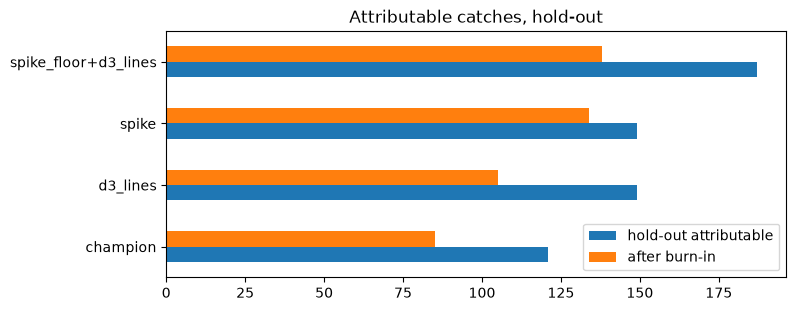

In [5]:
b = pd.DataFrame({n: {"hold-out attributable": r[n]["hold_out"]["attributable_tp"],
                      "after burn-in": r[n]["hold_out_after_burn_in"]["attributable_tp"],
                      "passes both conditions": r[n]["conditions"]["all_passed"]} for n in names}).T
print(b)
b[["hold-out attributable", "after burn-in"]].plot.barh(figsize=(8, 3.2), title="Attributable catches, hold-out");

**Read it.** The spike hybrid still leads after the burn-in, but by 33 rather than 38 over D3's lines, and only
the champion and D3's lines pass both conditions. The first draft of D7 compared the hybrid with the champion only.

## Exercise 5 — the pass mark decides the verdict

The D7 challenger's third point: the volatility condition passes or fails depending on the σ chosen. Sweep it.

rule   champion  d3_lines  spike_floor+d3_lines
sigma                                          
0.1       0.010     0.029                 0.078
0.2       0.038     0.074                 0.251
0.3       0.082     0.150                 0.549


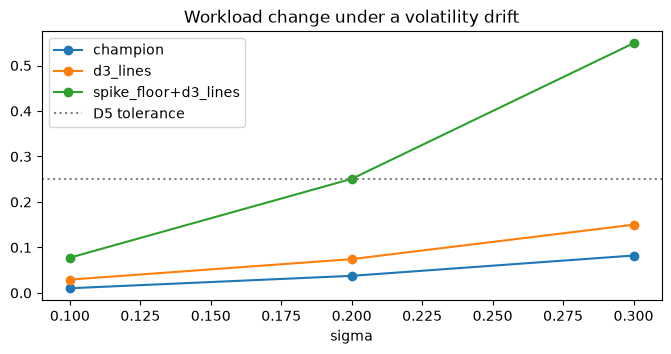

In [6]:
spike = ev["spike_spec"]
floored = {**spike, "floor": d7["assumptions"]["floor_variant"]}
d3 = d7["assumptions"]["fallbacks"]["d3_lines"]
fit = tm_sim.generate()
cands = {"champion": ("amount", ev["champion_threshold"]), "d3_lines": ("lines", d3),
         "spike_floor+d3_lines": ("spike", floored, d3)}
base = {n: validation._score(fit, validation.fired(fit, c))["workload"] for n, c in cands.items()}
rows = []
for sigma in (0.1, 0.2, 0.3):
    v = validation.volatile(fit, sigma, 20260928)
    for n, c in cands.items():
        rows.append({"sigma": sigma, "rule": n,
                     "workload change": validation._score(v, validation.fired(v, c))["workload"] / base[n] - 1})
s = pd.DataFrame(rows).pivot(index="sigma", columns="rule", values="workload change")
print(s.round(3))
ax = s.plot(marker="o", figsize=(8, 3.5), title="Workload change under a volatility drift")
ax.axhline(0.25, color="grey", ls=":", label="D5 tolerance"); ax.legend();

**Read it.** At σ 0.1 every rule passes; at 0.3 only the flat rules do. The finding (the ratio rule is sensitive)
is robust; the pass/fail line is a choice, and D7 records it as stated, not derived.

## Exercise 6 — the paper, generated from the records

In [7]:
text = paper.render()
print([l for l in text.splitlines() if l.startswith("## ")])
print(text[text.index("## 4. Recommendation"):text.index("## 5. Limitations")][:1400])

['## 1. Background', '## 2. Method', '## 3. Results', '## 4. Recommendation', '## 5. Limitations']
## 4. Recommendation

The latest decision is **D7 (HOLD)**. Week 10's capstone: judge D3's lines against the conditions on a hold-out seed no decision has used, plant at least one typology that is not a relative spike (D4 challenge, point 1), and only then take an apply decision -- which first needs the registry to hold per-segment lines.

What the governed apply step does with each decision today:

| Decision | Apply step |
|---|---|
| D1 | NOTHING_TO_APPLY |
| D2 | NOTHING_TO_APPLY |
| D3 | REFUSED: D3 sets per-segment lines, and the registry has no rule kind that can hold them (kinds: ['amount_above']); the step will not invent one |
| D4 | NOTHING_TO_APPLY |
| D5 | NOTHING_TO_APPLY |
| D6 | NOTHING_TO_APPLY |
| D7 | NOTHING_TO_APPLY |




## For the weekend note

Fill in `weekend_note.md`: the three rules against the conditions, what the challenge changed and why before the
commit, what the apply step would refuse, and the two limitations you would put first to a committee.